In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['CUDA_VISIBLE_DEVICES'] = '2'
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

In [2]:
import jax
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, SetupKLConfig, get_builders, plot_arrays, map_signal

jax.config.update("jax_enable_x64", True)

jwst not installed. Some JWST functions will not work.
shapely not installed. Some JWST functions will not work.


/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def box_markers(cfg, ps_map, grid, it):
    import numpy as np
    from aim_resolve import draw_boxes

    px, py = np.argwhere(ps_map == 1).T
    ps_mrk = dict(x=px, y=py, s=10, c='white', marker='+')
    box_map = draw_boxes(cfg.sections, grid, it)
    ox, oy = np.argwhere(box_map == 1).T
    oj_mrk = dict(x=ox, y=oy, s=0.1, c='white', marker=',')
    
    return dict(ps_mrk=ps_mrk, oj_mrk=oj_mrk)

In [4]:
dir = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_1f_1024_1z_b'

sf_rec = '3_rec_2z'
sf_it = 4

ARCMIN2RAD = np.pi / 60 / 180
AS2RAD = ARCMIN2RAD / 60
CONV_FACTOR = 1000 * AS2RAD**2


opt_yml = f'{dir}/opt/{sf_rec}/opt.yml'
print('load:', opt_yml)

optim_cfg = OptimizeKLConfig.from_file(opt_yml, get_builders, 'major')
optim_cfg.sections['data.0']['fname'] = '/Users/rf/Development/data/eso_986-1137mhz.npz'

sky_sf = optim_cfg.instantiate_sec(f'sky.{sf_it}')
print('sky components:', [c.prefix for c in sky_sf.models])

with open(f'{dir}/opt/{sf_rec}/last.pkl', "rb") as f:
    samples_sf, *_ = pickle.load(f)
print('samples:', len(samples_sf))

setup_cfg = SetupKLConfig.from_file(opt_yml)
sky_ps = sky_sf.points[0]
ps_map = map_signal(sky_ps.points.grid, sky_ps.grid)(np.ones(sky_ps.shape))
markers_sf = box_markers(setup_cfg, ps_map, sky_sf.grid, sf_it)
print('markers:', [f'{k}: {len(v["x"])}' for k, v in markers_sf.items()])

load: /Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_1f_1024_1z_b/opt/3_rec_2z/opt.yml
sky components: ['bg.4', 'p0.4', 'o0.4', 'o1.4', 'o2.4', 't0.4']
samples: 4
markers: ['ps_mrk: 156', 'oj_mrk: 35550']


In [5]:
min_sf = 1e-3
max_sf = np.max(samples_sf.mean(sky_sf) * CONV_FACTOR)
print('vmin:', min_sf, '\nvmax:', max_sf)

plot_dict = dict(
    name = None,
    odir = None,
    norm = 'log',
    vmin = min_sf,
    vmax = max_sf,
    cmap = 'inferno',
    cbar = False,
    ticks = 0,
    dpi=300,
)

vmin: 0.001 
vmax: 5.561395204149101


plotting ...


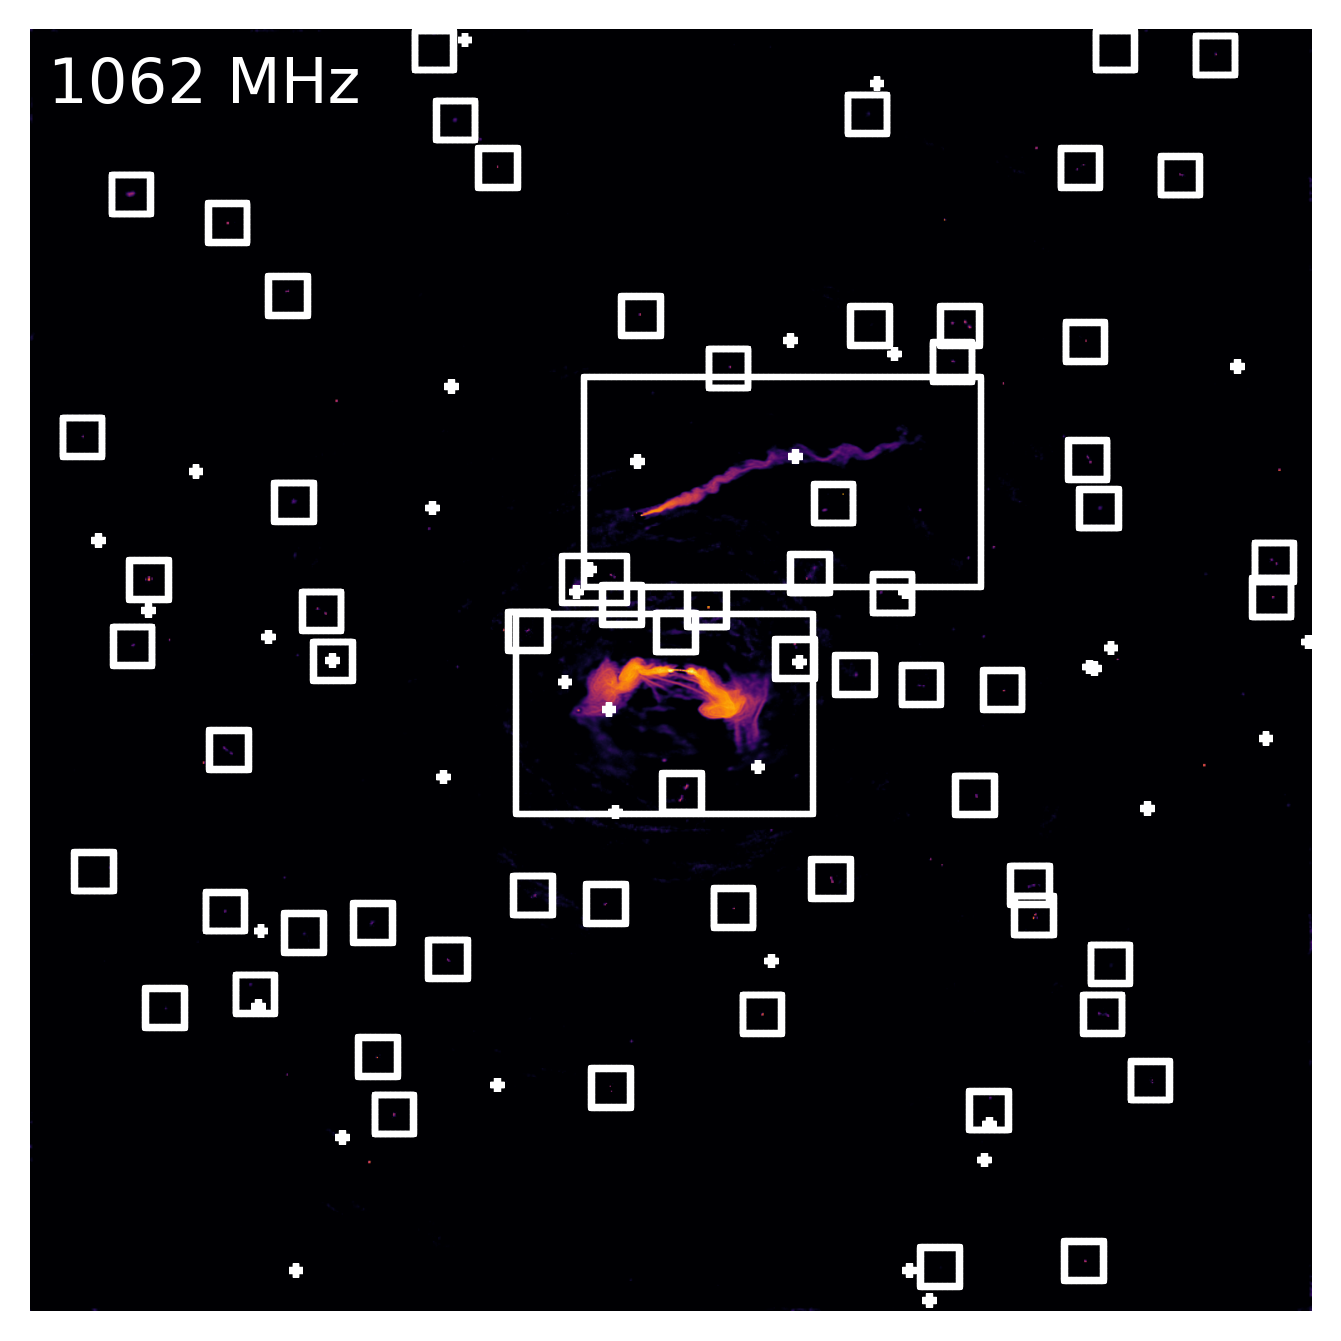

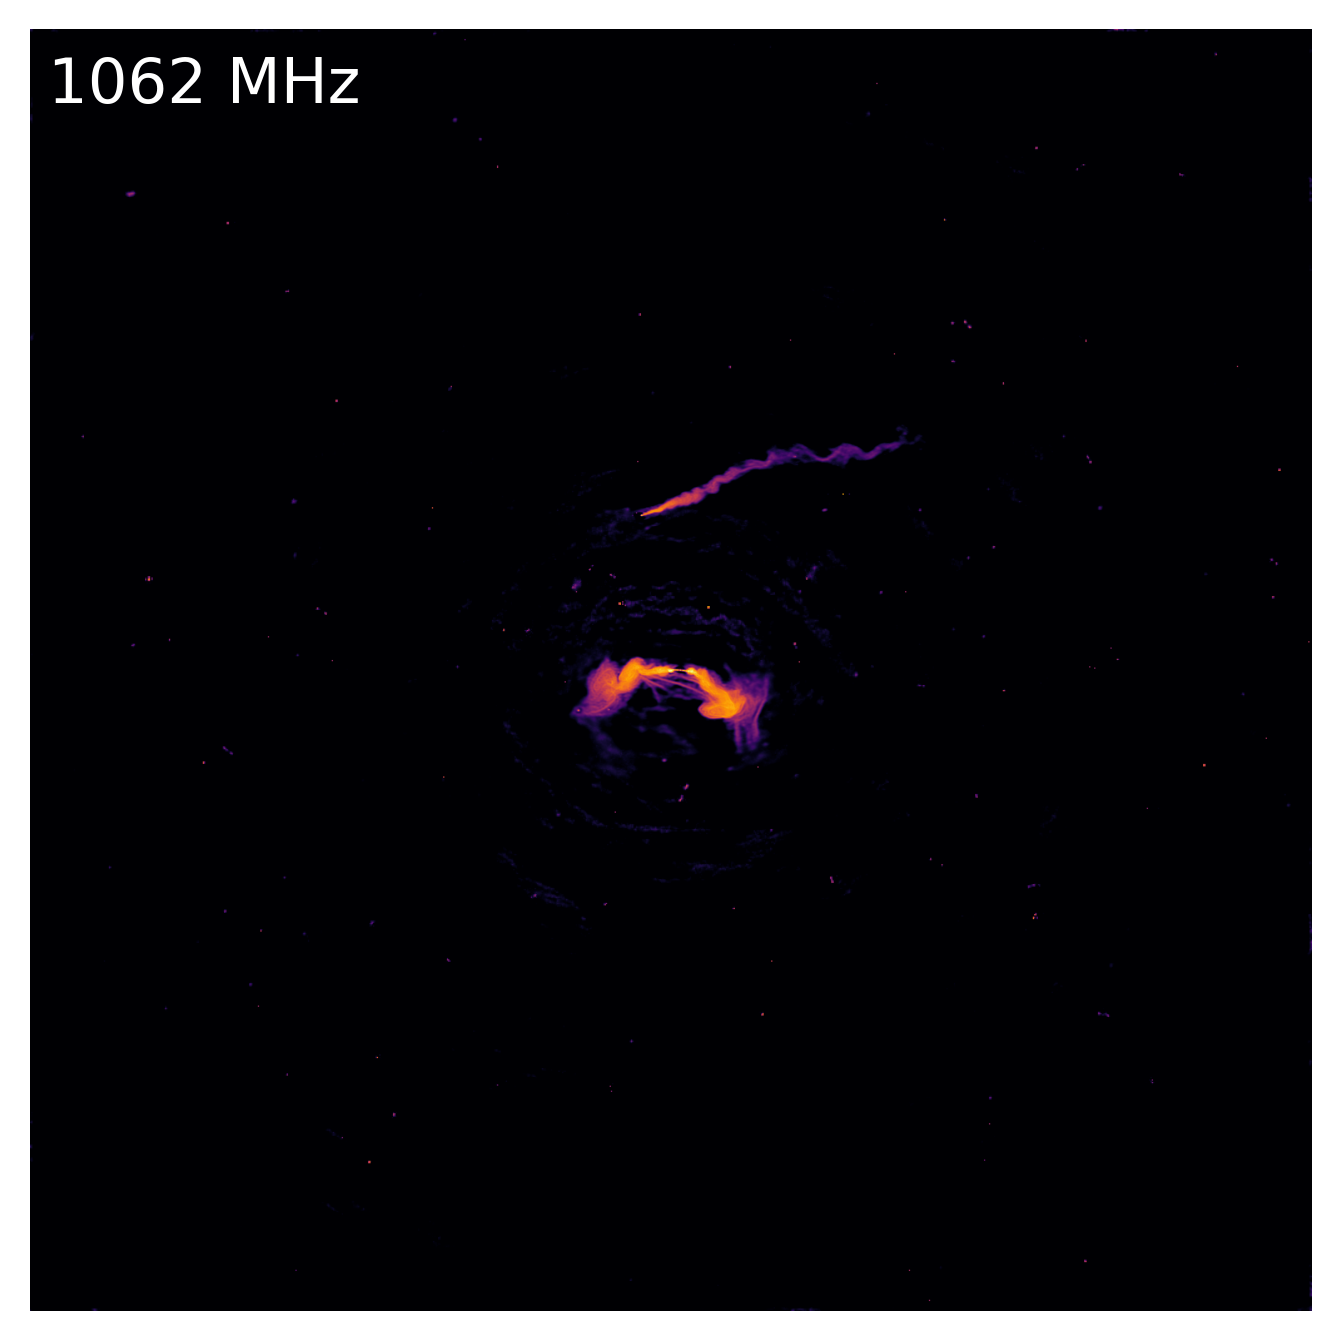

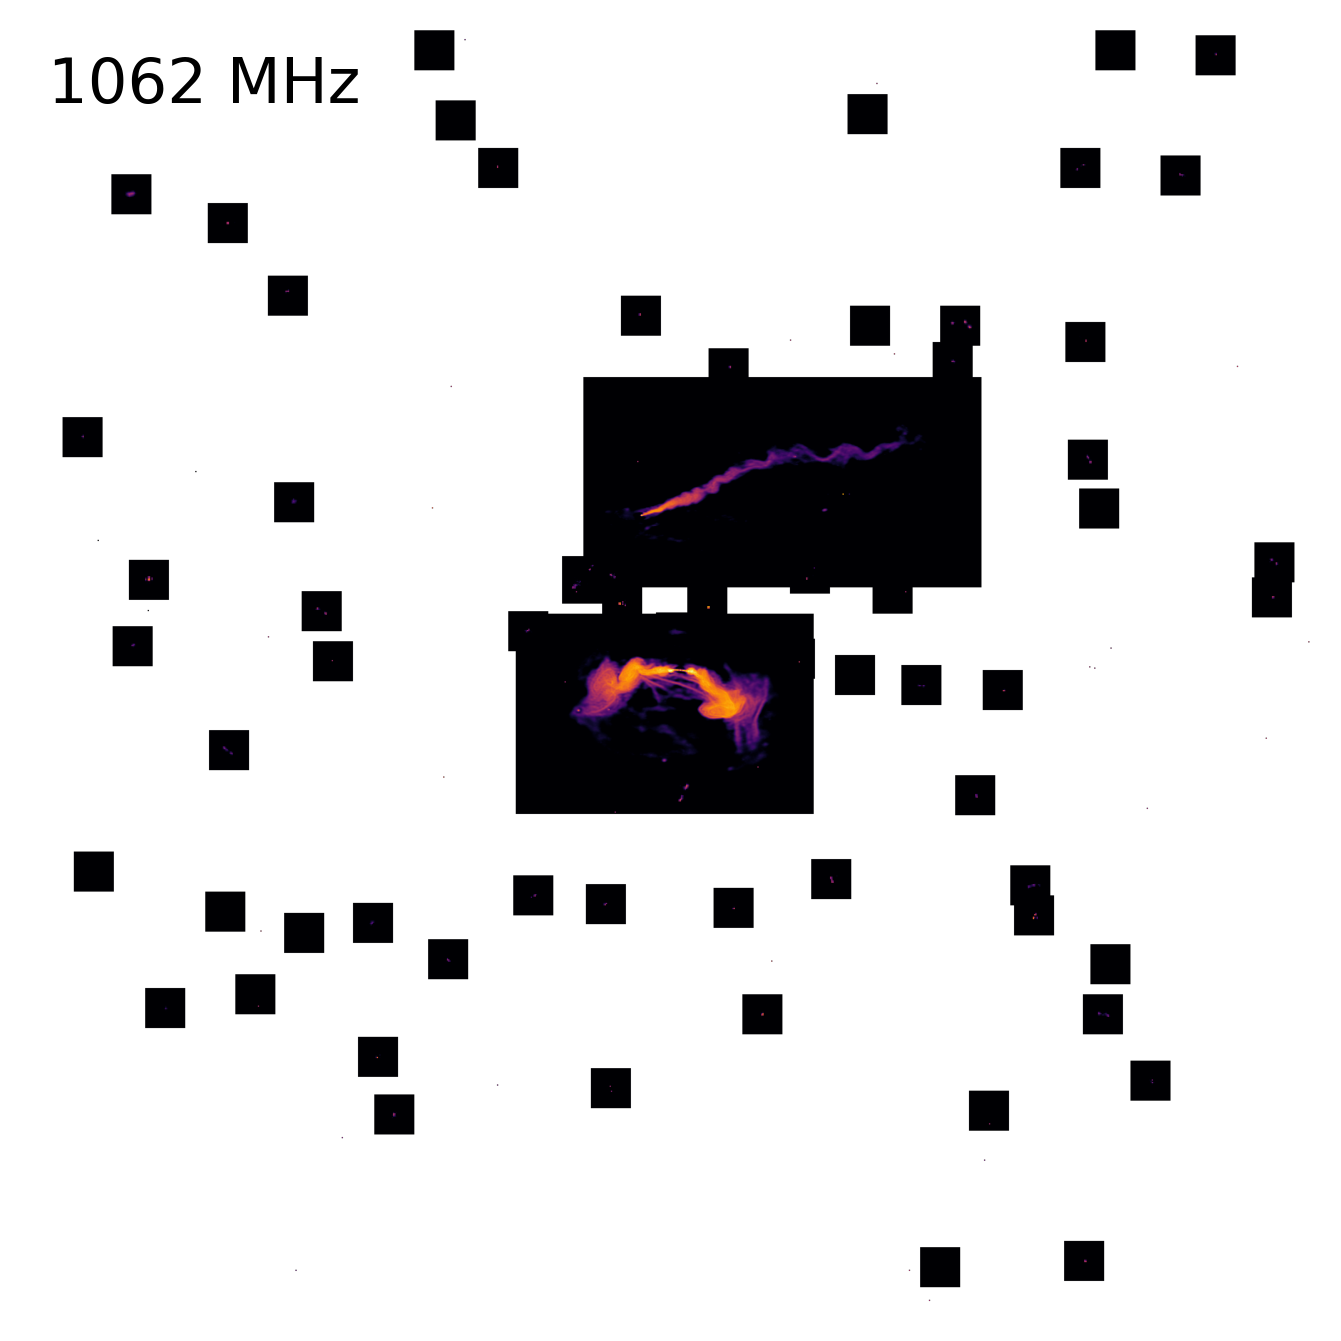

In [12]:
sky_mean_sf = samples_sf.mean(sky_sf) * CONV_FACTOR

pot_mean_sf = samples_sf.mean(sky_sf.points_and_objects) * CONV_FACTOR


print('plotting ...')
plot_arrays(
    array = sky_mean_sf, 
    marker = markers_sf,
    callback = lambda fig, ax: fig.text(0.085, 0.90, '1062 MHz', fontsize=15, c='white'),
    **plot_dict,
)
plot_arrays(
    array = sky_mean_sf, 
    callback = lambda fig, ax: fig.text(0.085, 0.90, '1062 MHz', fontsize=15, c='white'),
    **plot_dict,
)
plot_arrays(
    array = pot_mean_sf, 
    callback = lambda fig, ax: fig.text(0.085, 0.90, '1062 MHz', fontsize=15, c='black'),
    **plot_dict,
)

plotting ...


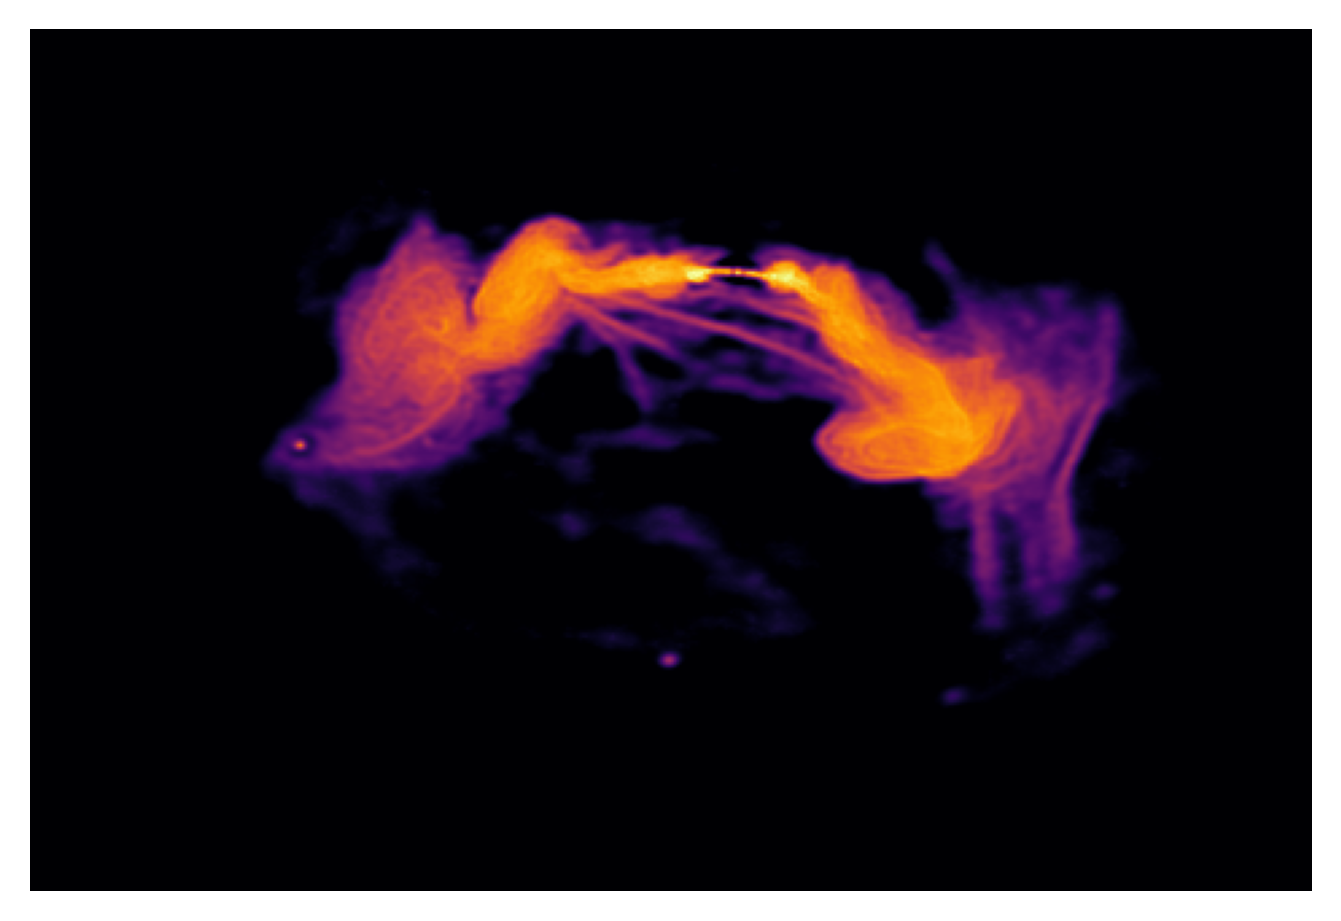

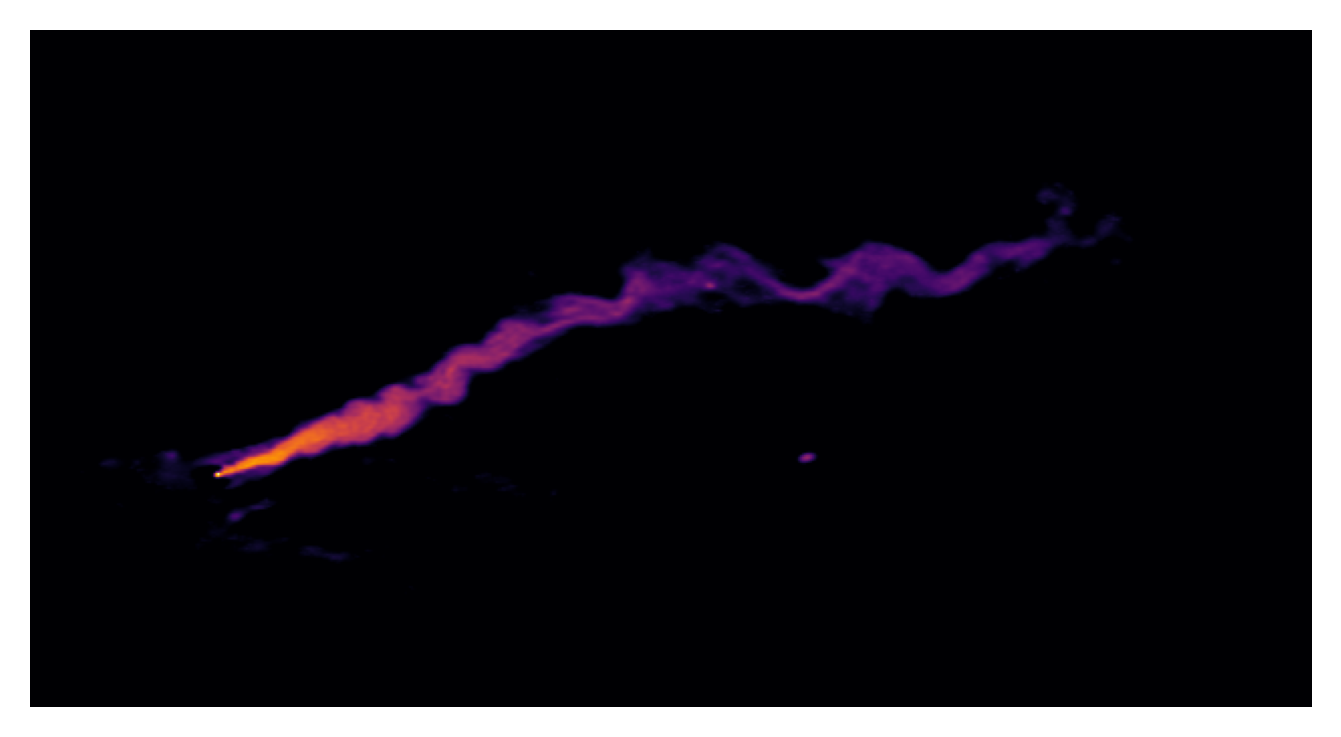

In [7]:
comp_mean_sf = [samples_sf.mean(c) * CONV_FACTOR for c in [sky_sf.objects[0], sky_sf.objects[1]]]


print('plotting ...')
for c in comp_mean_sf:
    plot_arrays(
        array = c, 
        **plot_dict,
    )

plotting ...


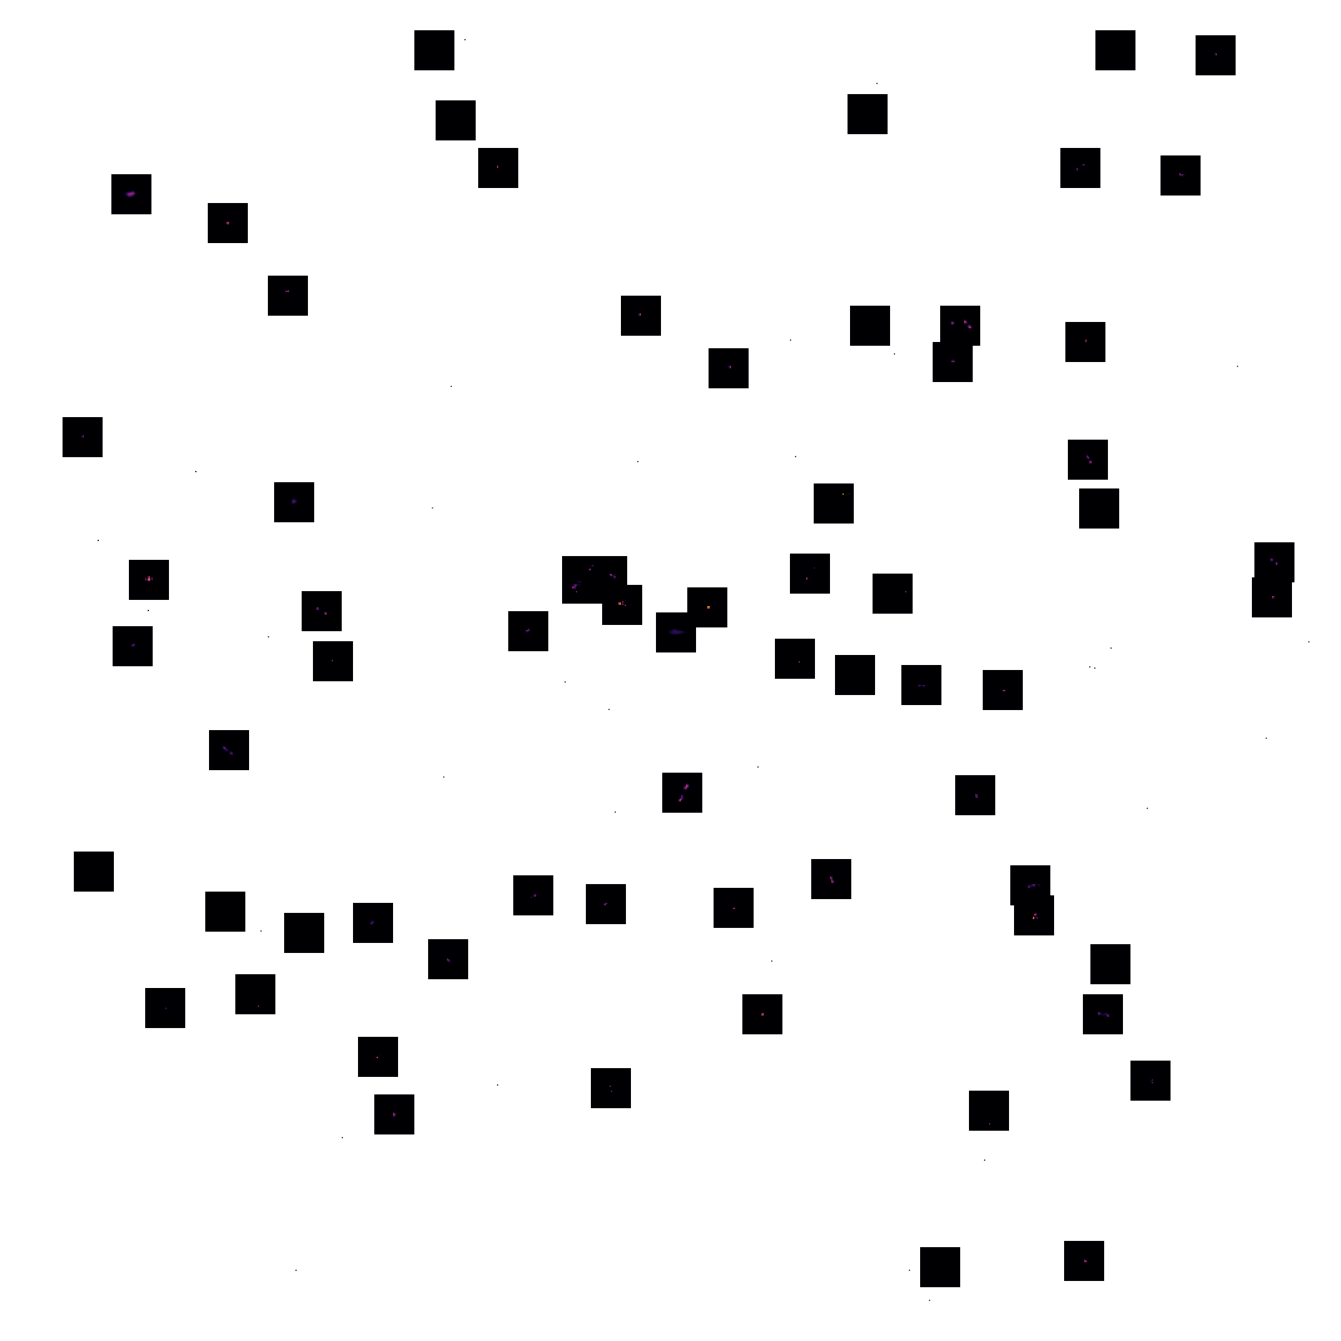

In [8]:
sky_pt_sf = sky_sf.copy()

pt_models = []
for m in sky_pt_sf.models:
    if m not in [sky_sf.background, sky_sf.objects[0], sky_sf.objects[1]]:
        pt_models.append(m)

sky_pt_sf.models = pt_models
pt_mean_sf = samples_sf.mean(sky_pt_sf) * CONV_FACTOR
        
        
print('plotting ...')
plot_arrays(
    array = pt_mean_sf, 
    **plot_dict,
)

plotting ...


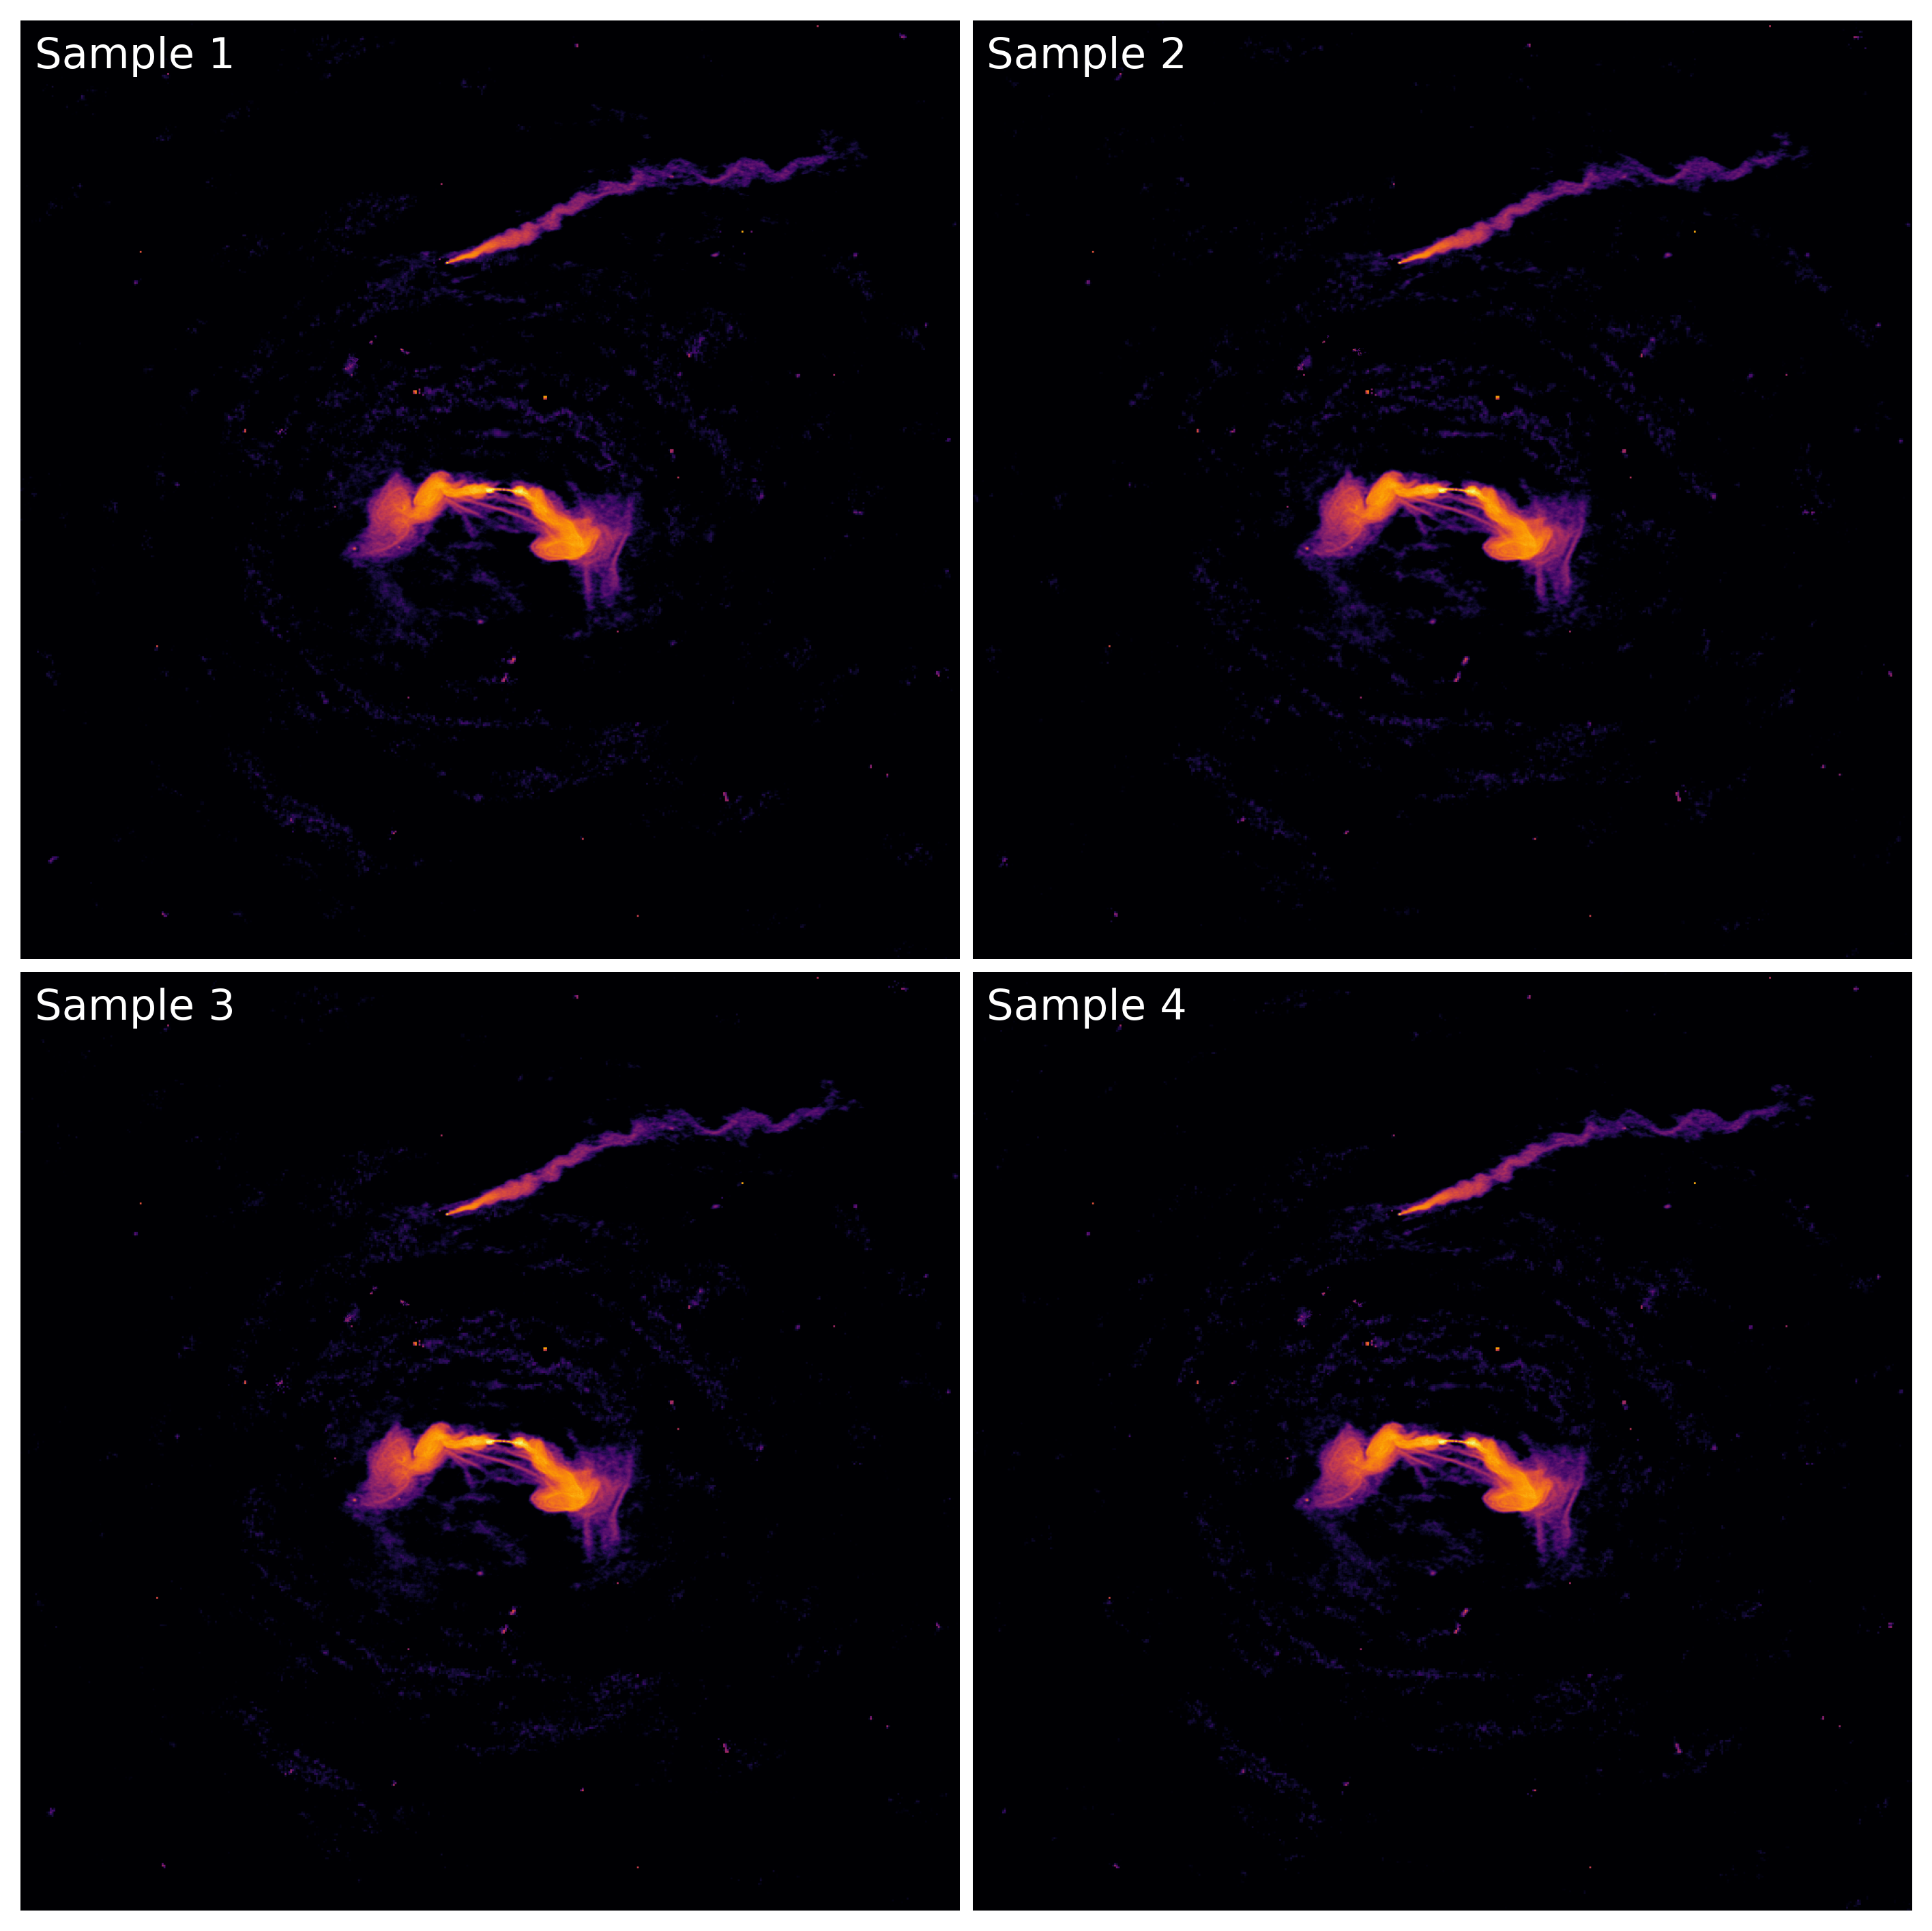

In [9]:
zoom = 2 


smp_val_sf = []
for smp in samples_sf:
    val = sky_sf(smp) * CONV_FACTOR
    if zoom > 1:
        grd = sky_sf.grid
        val = map_signal(grd, grd.update(space=grd.spc//2))(val)
    smp_val_sf.append(val)


def callback(fig, axes):
    fig.text(0.045, 0.950, 'Sample 1', fontsize=15, c='white')
    fig.text(0.51, 0.950, 'Sample 2', fontsize=15, c='white')
    fig.text(0.045, 0.485, 'Sample 3', fontsize=15, c='white')
    fig.text(0.51, 0.485, 'Sample 4', fontsize=15, c='white')


print('plotting ...')
plot_arrays(
    smp_val_sf, 
    rows=2,
    grid_kwargs=dict(hspace=-0.71, wspace=-0.7, width_ratios=[1,1], height_ratios=[1,1]),
    callback=callback,
    **plot_dict,
)

plotting ...


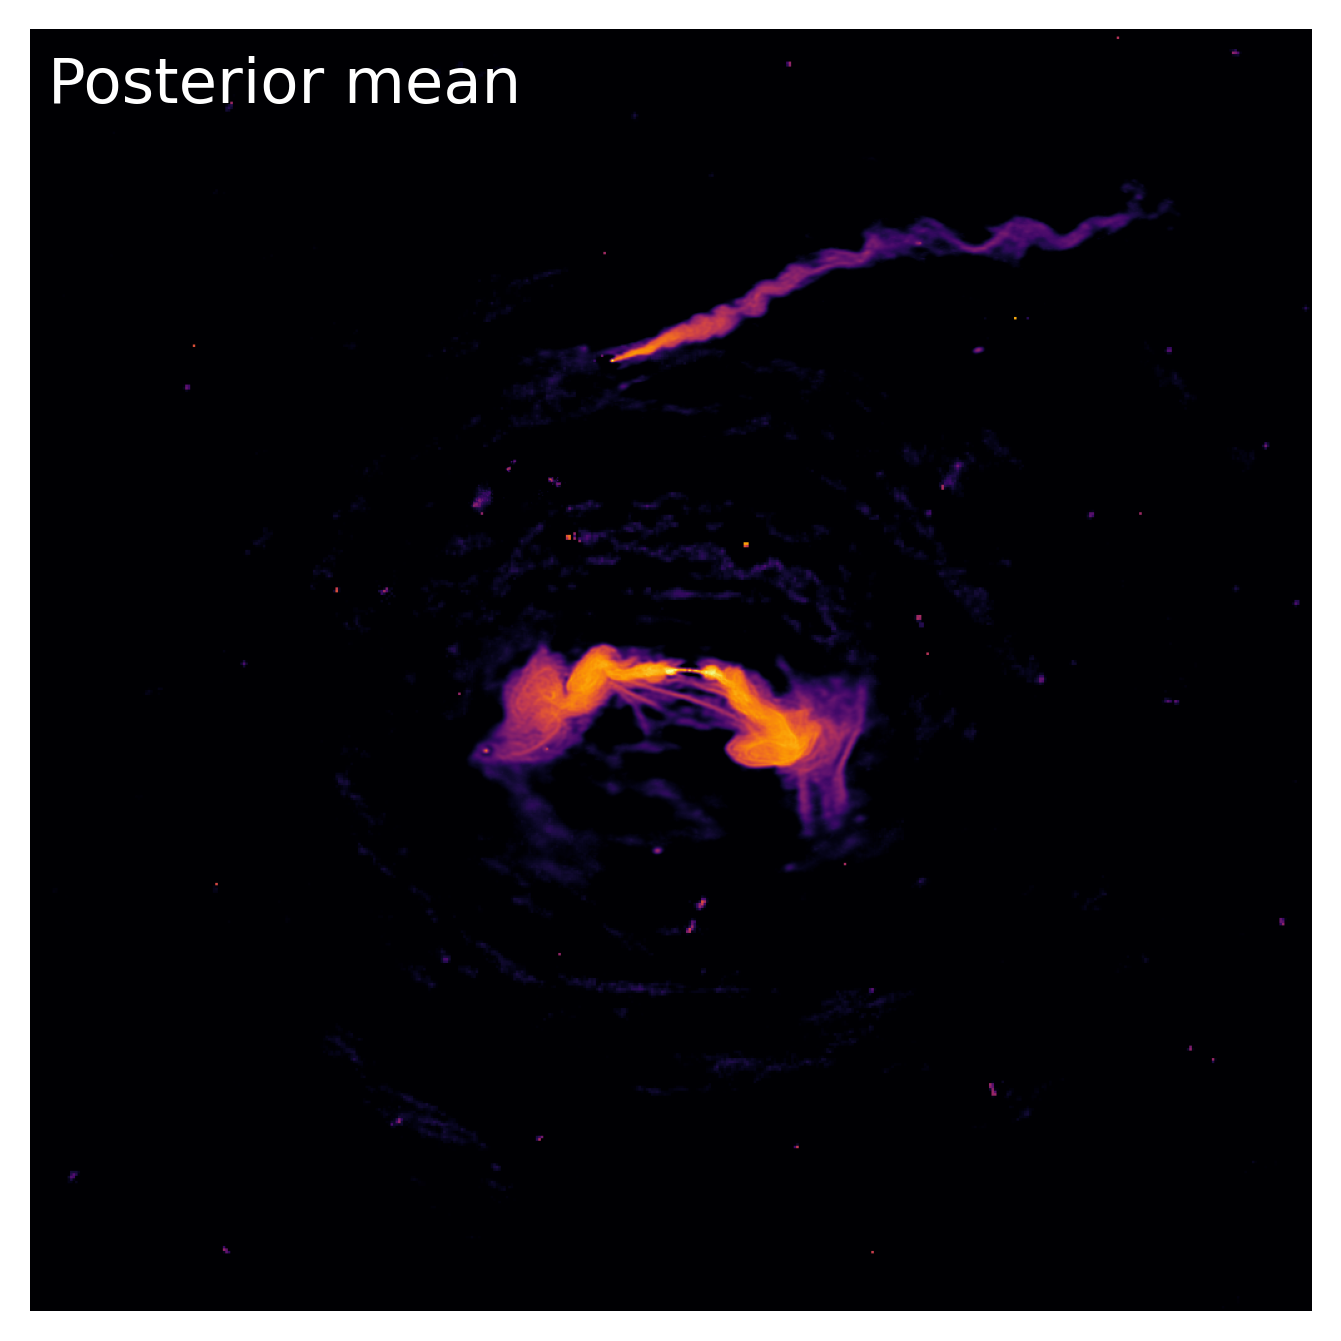

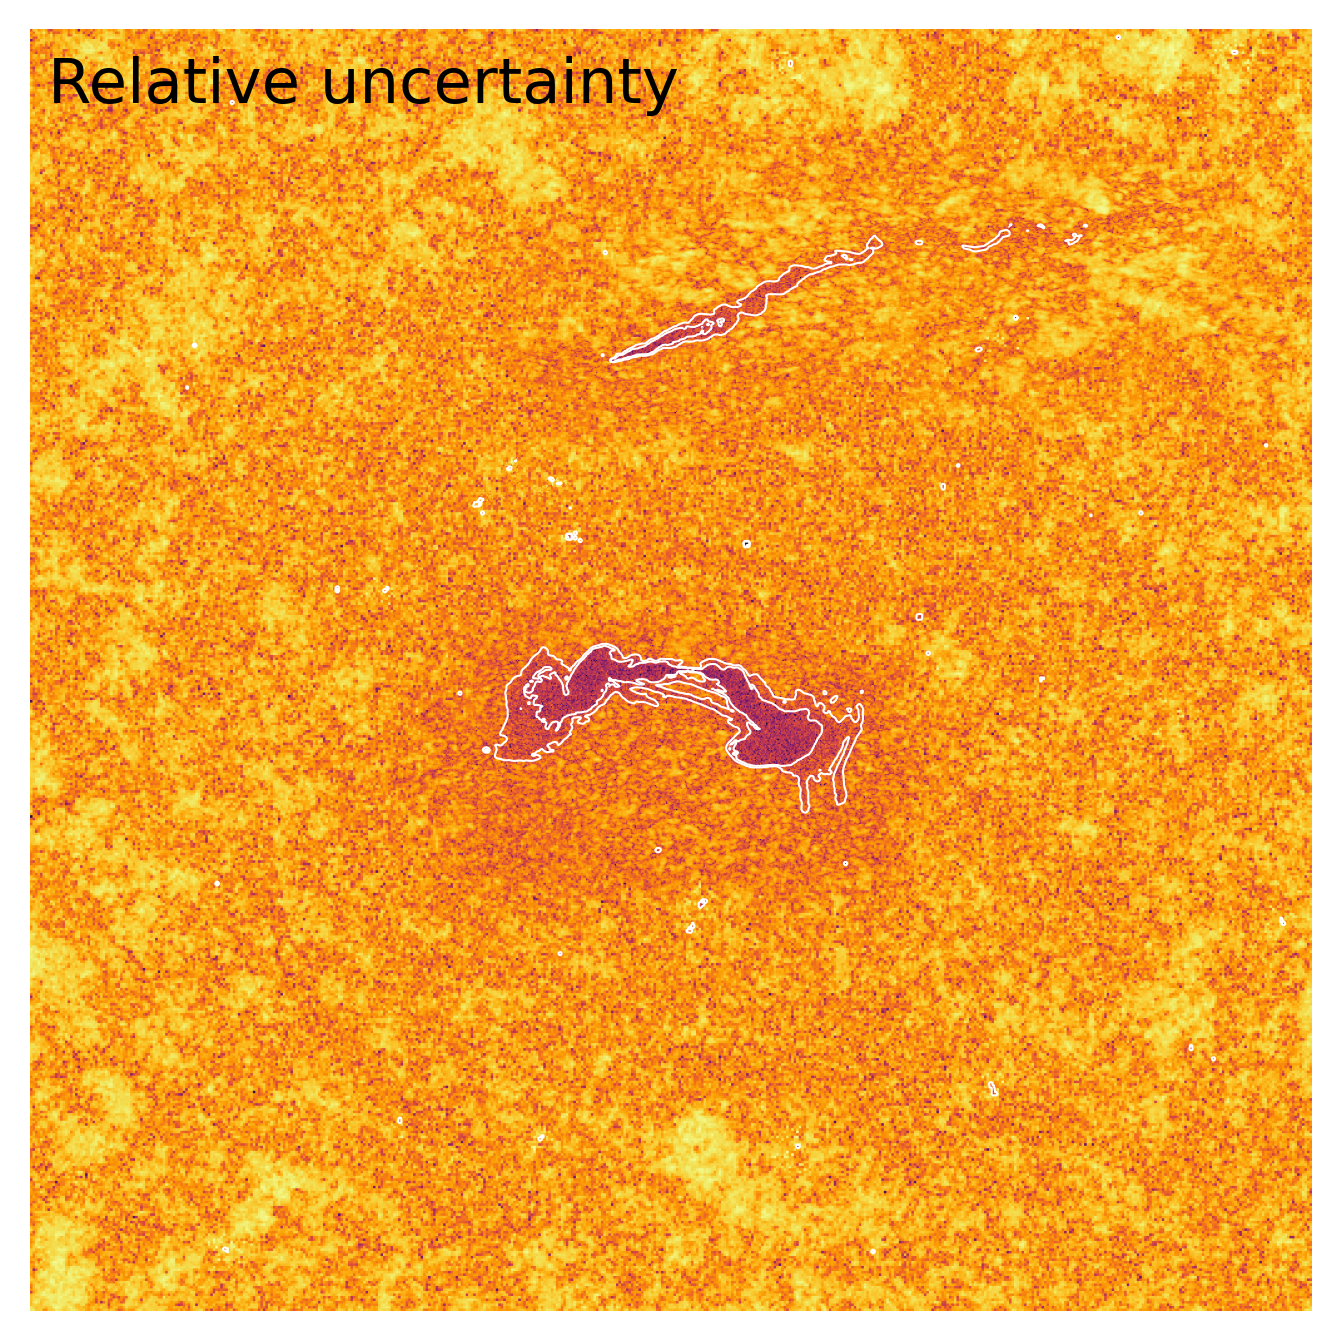

In [10]:
zoom = 2

mean, std = samples_sf.mean_and_std(sky_sf)
skyz_mean_sf = mean * CONV_FACTOR
skyz_runc_sf = std / mean
if zoom:
    grd = sky_sf.grid
    skyz_mean_sf = map_signal(grd, grd.update(space=grd.spc//2))(skyz_mean_sf)
    skyz_runc_sf = map_signal(grd, grd.update(space=grd.spc//2))(skyz_runc_sf)


print('plotting ...')
plot_arrays(
    array = skyz_mean_sf, 
    callback = lambda fig, ax: fig.text(0.085, 0.90, 'Posterior mean', fontsize=15, c='white'),
    **plot_dict,
)
plot_arrays(
    array = skyz_runc_sf,
    contour={'array': skyz_mean_sf, 'colors': 'white', 'levels': [1e-2, 1e-1], 'linewidths': 0.5},
    callback = lambda fig, ax: fig.text(0.085, 0.90, 'Relative uncertainty', fontsize=15, c='black'),
    **plot_dict | dict(vmin=None, vmax=None),
)